
📊 BASIC STATISTICS
Real Mean: 135.81799579743648
Simulated Mean: 112.4922824303144
Real Variance: 1449.1963360115699
Simulated Variance: 2836.4238694252085


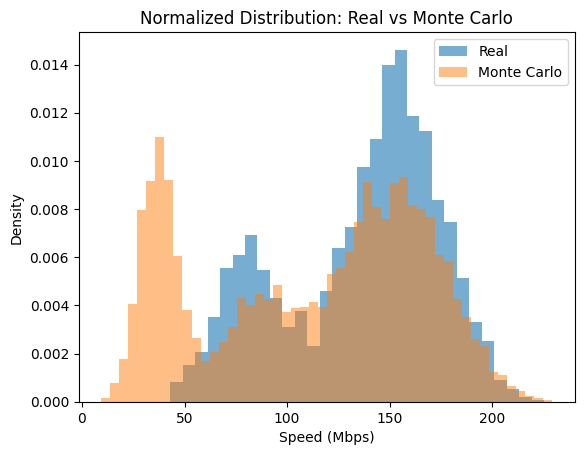

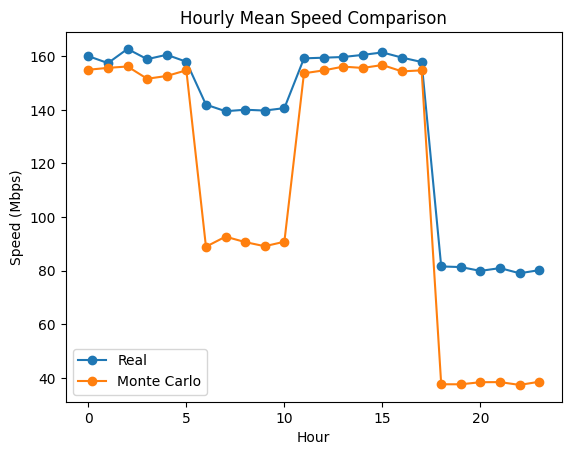

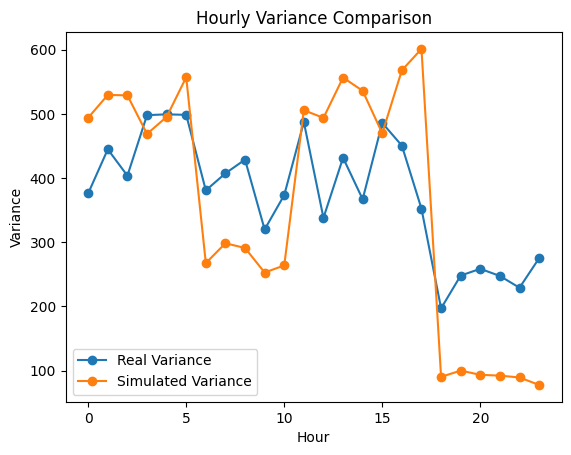

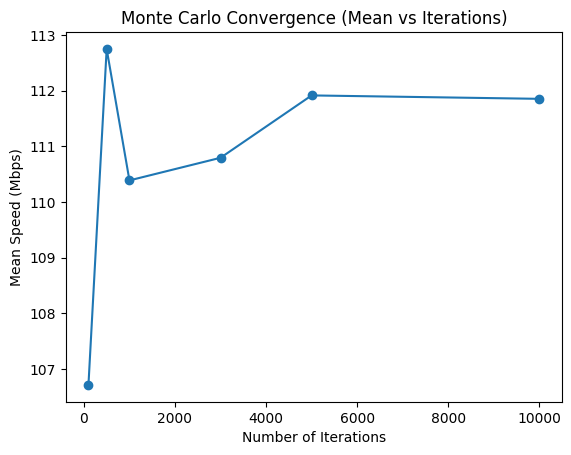

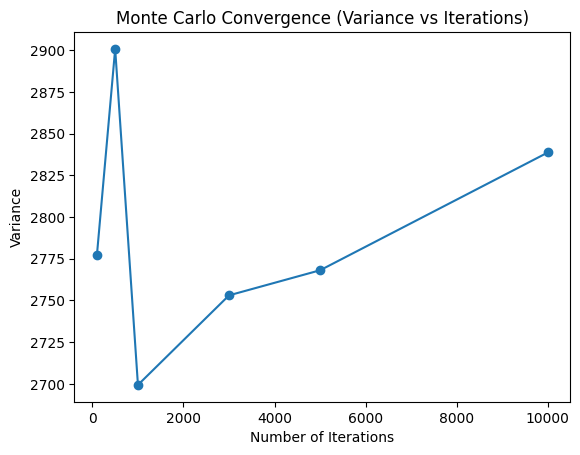

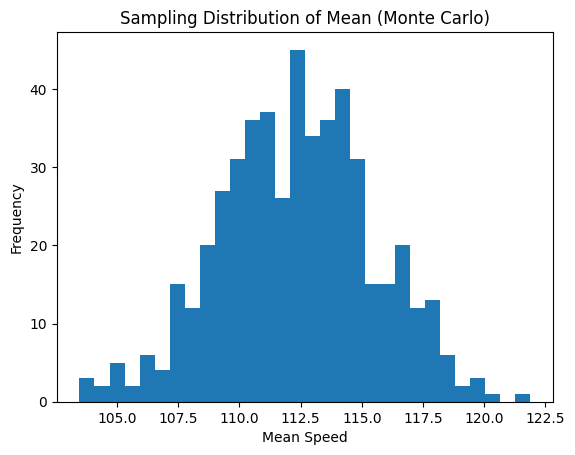

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# =========================================================
# 1. 📦 GENERATE MULTI-USER REALISTIC DATA (24 HOURS)
# =========================================================
def generate_realistic_data(n_users=100):
    data = []

    for user in range(n_users):
        for hour in range(24):

            if 18 <= hour <= 23:  # peak
                base = np.random.normal(80, 15)
            elif 6 <= hour <= 10:  # morning moderate
                base = np.random.normal(140, 20)
            else:  # off-peak
                base = np.random.normal(160, 20)

            noise = np.random.normal(0, 5)
            speed = max(base + noise, 5)

            data.append([user, hour, speed])

    return pd.DataFrame(data, columns=["user_id", "hour", "speed"])


real_data = generate_realistic_data(100)
real_speeds = real_data["speed"].values

# =========================================================
# 2. 🎲 MONTE CARLO SIMULATION (TIME-AWARE)
# =========================================================
def simulate_time_based(n=8000):
    speeds = []
    hours = []

    for _ in range(n):
        hour = np.random.randint(0, 24)

        if 18 <= hour <= 23:
            users = np.random.poisson(85)
            capacity = np.random.normal(150, 25)
            alpha = 0.035
        elif 6 <= hour <= 10:
            users = np.random.poisson(50)
            capacity = np.random.normal(180, 20)
            alpha = 0.02
        else:
            users = np.random.poisson(30)
            capacity = np.random.normal(200, 15)
            alpha = 0.01

        efficiency = np.random.uniform(0.8, 1.2)
        noise = np.random.normal(0, 5)

        speed = (capacity * efficiency) / (1 + alpha * users) + noise

        speeds.append(speed)
        hours.append(hour)

    return pd.DataFrame({"hour": hours, "speed": speeds})


simulated_df = simulate_time_based()
simulated = simulated_df["speed"].values

# =========================================================
# 3. 📊 BASIC COMPARISON: MEAN & VARIANCE
# =========================================================
print("\n📊 BASIC STATISTICS")
print("Real Mean:", np.mean(real_speeds))
print("Simulated Mean:", np.mean(simulated))

print("Real Variance:", np.var(real_speeds))
print("Simulated Variance:", np.var(simulated))

# =========================================================
# 4. 📈 PLOT 1: DISTRIBUTION COMPARISON (NORMALIZED)
# =========================================================
plt.figure()
plt.hist(real_speeds, bins=30, density=True, alpha=0.6, label="Real")
plt.hist(simulated, bins=50, density=True, alpha=0.5, label="Monte Carlo")
plt.title("Normalized Distribution: Real vs Monte Carlo")
plt.xlabel("Speed (Mbps)")
plt.ylabel("Density")
plt.legend()
plt.show()

# =========================================================
# 5. 📈 PLOT 2: HOURLY MEAN COMPARISON
# =========================================================
real_hourly = real_data.groupby("hour")["speed"].mean()
sim_hourly = simulated_df.groupby("hour")["speed"].mean()

plt.figure()
plt.plot(real_hourly.index, real_hourly.values, marker='o', label="Real")
plt.plot(sim_hourly.index, sim_hourly.values, marker='o', label="Monte Carlo")
plt.title("Hourly Mean Speed Comparison")
plt.xlabel("Hour")
plt.ylabel("Speed (Mbps)")
plt.legend()
plt.show()

# =========================================================
# 6. 📉 PLOT 3: HOURLY VARIANCE COMPARISON
# =========================================================
real_var_hourly = real_data.groupby("hour")["speed"].var()
sim_var_hourly = simulated_df.groupby("hour")["speed"].var()

plt.figure()
plt.plot(real_var_hourly.index, real_var_hourly.values, marker='o', label="Real Variance")
plt.plot(sim_var_hourly.index, sim_var_hourly.values, marker='o', label="Simulated Variance")
plt.title("Hourly Variance Comparison")
plt.xlabel("Hour")
plt.ylabel("Variance")
plt.legend()
plt.show()

# =========================================================
# 7. 📊 PLOT 4: MONTE CARLO CONVERGENCE
# =========================================================
sizes = [100, 500, 1000, 3000, 5000, 10000]
means = []

for n in sizes:
    sim = simulate_time_based(n)["speed"]
    means.append(np.mean(sim))

plt.figure()
plt.plot(sizes, means, marker='o')
plt.title("Monte Carlo Convergence (Mean vs Iterations)")
plt.xlabel("Number of Iterations")
plt.ylabel("Mean Speed (Mbps)")
plt.show()

# =========================================================
# 8. 📊 PLOT 5: VARIANCE CONVERGENCE
# =========================================================
variances = []

for n in sizes:
    sim = simulate_time_based(n)["speed"]
    variances.append(np.var(sim))

plt.figure()
plt.plot(sizes, variances, marker='o')
plt.title("Monte Carlo Convergence (Variance vs Iterations)")
plt.xlabel("Number of Iterations")
plt.ylabel("Variance")
plt.show()

# =========================================================
# 9. 📊 PLOT 6: SAMPLE MEAN STABILITY
# =========================================================
means_sample = []

for _ in range(500):
    sample = np.random.choice(simulated, 300)
    means_sample.append(np.mean(sample))

plt.figure()
plt.hist(means_sample, bins=30)
plt.title("Sampling Distribution of Mean (Monte Carlo)")
plt.xlabel("Mean Speed")
plt.ylabel("Frequency")
plt.show()